<a href="https://colab.research.google.com/github/Rakmik/NM/blob/main/%D0%9B%D0%A0%E2%84%968_%D0%97%D0%B0%D0%B3%D0%B8%D0%BD%D0%B0%D0%B9%D0%BA%D0%BE_%D0%9F%D0%B0%D0%B2%D0%BB%D0%BE_%D0%A4%D0%86%D0%A2_2_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Варіант 8

#Загинайко Павло

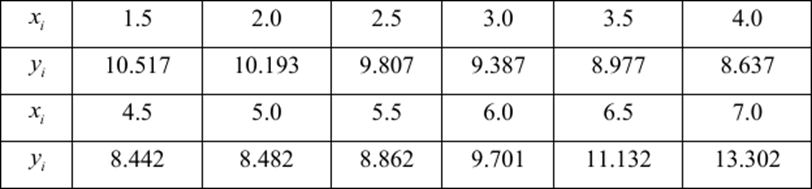

In [35]:
import numpy as np

# Варіант 1

# Дані

In [36]:
x_values = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])
y_values = np.array([10.517, 10.193, 9.807, 9.387, 8.977, 8.637, 8.442, 8.482, 8.862, 9.701, 11.132, 13.302])

# Крок таблиці
h = 0.5

# Обчислення кінцевих різниць

In [37]:
def finite_differences(y):
    n = len(y)
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]

    return delta_y

# Tаблиця кінцевих різниць

In [38]:
delta_table = finite_differences(y_values)

# Вивід таблиці
print("Таблиця кінцевих різниць:")

np.set_printoptions(precision=4, suppress=True, linewidth=100)
print(delta_table[:, :6])

Таблиця кінцевих різниць:
[[10.517 -0.324 -0.062  0.028  0.016 -0.   ]
 [10.193 -0.386 -0.034  0.044  0.016 -0.001]
 [ 9.807 -0.42   0.01   0.06   0.015  0.   ]
 [ 9.387 -0.41   0.07   0.075  0.015  0.   ]
 [ 8.977 -0.34   0.145  0.09   0.015 -0.001]
 [ 8.637 -0.195  0.235  0.105  0.014  0.   ]
 [ 8.442  0.04   0.34   0.119  0.014  0.   ]
 [ 8.482  0.38   0.459  0.133  0.014  0.   ]
 [ 8.862  0.839  0.592  0.147  0.     0.   ]
 [ 9.701  1.431  0.739  0.     0.     0.   ]
 [11.132  2.17   0.     0.     0.     0.   ]
 [13.302  0.     0.     0.     0.     0.   ]]


# Визначаємо індекс для точки x = 3.0

In [39]:
idx = 3

# Беремо різниці саме для цієї точки
delta_y1 = delta_table[idx, 1]
delta2_y1 = delta_table[idx, 2]
delta3_y1 = delta_table[idx, 3]
delta4_y1 = delta_table[idx, 4]

# Обчислення похідних за формулами Ньютона
y1_prime = (delta_y1 - delta2_y1 / 2 + delta3_y1 / 3 - delta4_y1 / 4) / h
y1_double_prime = (delta2_y1 - delta3_y1 + 11 / 12 * delta4_y1) / h**2

# Вивід результатів

In [40]:
print(f"\nПерша похідна y'(3.0) ≈ {round(y1_prime, 3)}")
print(f"Друга похідна y''(3.0) ≈ {round(y1_double_prime, 3)}")


Перша похідна y'(3.0) ≈ -0.848
Друга похідна y''(3.0) ≈ 0.035


# Варіант 2

# Таблиця значень функції

In [41]:
x_values = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])
y_values = np.array([10.517, 10.193, 9.807, 9.387, 8.977, 8.637, 8.442, 8.482, 8.862, 9.701, 11.132, 13.302])

# Крок таблиці (h = 0.5)
h = x_values[1] - x_values[0]

# Знаходимо індекс точки x = 3.0
idx = np.where(x_values == 3.0)[0][0]

# Обчислення похідних

In [42]:
# f'(x) ≈ (y[i+1] - y[i]) / h
first_derivative = (y_values[1:] - y_values[:-1]) / h

# Обчислення другої похідної
# f''(x) ≈ (y[i+2] - 2y[i+1] + y[i]) / h^2
second_derivative = (first_derivative[1:] - first_derivative[:-1]) / h

# Виведення результатів

In [43]:
print(f"Результати для x = {x_values[idx]}:")
print("---")

# Перша похідна в точці x = 3.0 (використовуємо значення в точці idx)
print("Перша похідна:")
print(f"f'(3.0) ≈ {round(first_derivative[idx], 3)}")

print("\nДруга похідна:")
# Друга похідна в точці x = 3.0
print(f"f''(3.0) ≈ {round(second_derivative[idx], 3)}")

Результати для x = 3.0:
---
Перша похідна:
f'(3.0) ≈ -0.82

Друга похідна:
f''(3.0) ≈ 0.28


# Графік функції та похідних


In [44]:
import matplotlib.pyplot as plt

# Чисельне диференціювання для графіків

In [45]:
x_node = 3.0
y_prime_excel = -0.848
y_double_prime_excel = 0.035

# 1. Обчислення першої похідної (central differences)
y_prime = np.gradient(y_values, x_values)

# 2. Обчислення другої похідної (знову gradient від першої похідної)
y_double_prime = np.gradient(y_prime, x_values)

# Побудова графіків

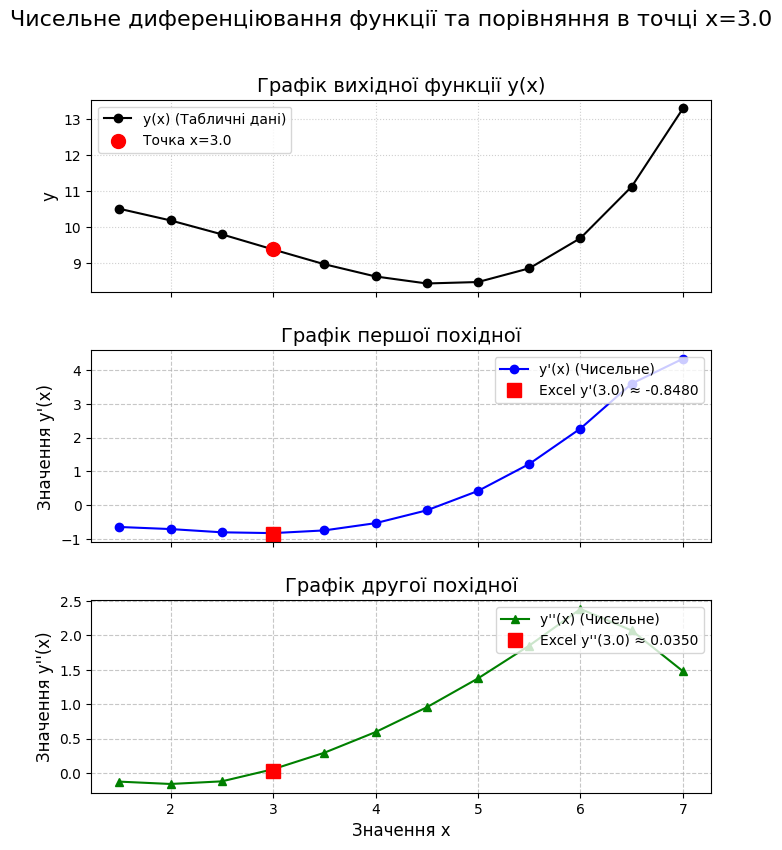

In [46]:
# Створення фігури
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
plt.subplots_adjust(hspace=0.3)

ax0.plot(x_values, y_values, 'k-o', label="y(x) (Табличні дані)")
ax0.scatter(3.0, 9.387, color='red', s=100, zorder=5, label="Точка x=3.0")
ax0.set_ylabel("y", fontsize=12)
ax0.set_title("Графік вихідної функції y(x)", fontsize=14)
ax0.grid(True, linestyle=':', alpha=0.6)
ax0.legend()

# Графік 1: Перша похідна
ax1.plot(x_values, y_prime, 'b-o', label="y'(x) (Чисельне)")
# Відмічаємо точку з Excel
ax1.plot(x_node, y_prime_excel, 'rs', markersize=10, label=f"Excel y'({x_node}) ≈ {y_prime_excel:.4f}")

ax1.set_ylabel("Значення y'(x)", fontsize=12)
ax1.set_title("Графік першої похідної", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper right')

# Графік 2: Друга похідна
ax2.plot(x_values, y_double_prime, 'g-^', label="y''(x) (Чисельне)")
# Відмічаємо точку з Excel
ax2.plot(x_node, y_double_prime_excel, 'rs', markersize=10, label=f"Excel y''({x_node}) ≈ {y_double_prime_excel:.4f}")

ax2.set_xlabel("Значення x", fontsize=12)
ax2.set_ylabel("Значення y''(x)", fontsize=12)
ax2.set_title("Графік другої похідної", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

# Додаємо загальну назву
fig.suptitle(f"Чисельне диференціювання функції та порівняння в точці x={x_node}", fontsize=16)

# Відобразити графік
plt.show()